In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/tokenized_access_logs.csv
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DescriptionDataCoSupplyChain.csv


In [2]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv', encoding='latin-1')

In [3]:
df.shape
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [4]:
df = df.drop(columns=['Product Description', 'Order Zipcode'])
df.shape

(180519, 51)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 51 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [6]:
drop_cols = [
    # leakage
    'Delivery Status', 'Days for shipping (real)', 'Order Status',
    # identifiers
    'Customer Email', 'Customer Fname', 'Customer Lname',
    'Customer Password', 'Customer Street',
    'Customer Id', 'Order Id', 'Order Customer Id', 'Order Item Id',
    'Order Item Cardprod Id', 'Product Card Id',
    'Category Id', 'Department Id', 'Product Category Id',
    'Product Image','Customer Zipcode'
]
df = df.drop(columns=drop_cols)
df.shape

(180519, 32)

In [7]:
pd.set_option('display.max_columns', None)
df.head(10)

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Latitude,Longitude,Market,Order City,Order Country,order date (DateOrders),Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,4,91.250000,314.640015,0,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,1/31/2018 22:56,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,4,-249.089996,311.359985,1,Sporting Goods,Caguas,Puerto Rico,Consumer,PR,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,1/13/2018 12:27,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,-247.779999,309.720001,0,Sporting Goods,San Jose,EE. UU.,Consumer,CA,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,1/13/2018 12:06,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,4,22.860001,304.809998,0,Sporting Goods,Los Angeles,EE. UU.,Home Office,CA,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,1/13/2018 11:45,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,4,134.210007,298.250000,0,Sporting Goods,Caguas,Puerto Rico,Corporate,PR,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,1/13/2018 11:24,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,Smart watch,327.75,0,1/15/2018 11:24,Standard Class
5,TRANSFER,4,18.580000,294.980011,0,Sporting Goods,Tonawanda,EE. UU.,Consumer,NY,Fitness,43.013969,-78.879066,Pacific Asia,Toowoomba,Australia,1/13/2018 11:03,32.779999,0.10,327.75,0.06,1,327.75,294.980011,18.580000,Oceania,Queensland,Smart watch,327.75,0,1/19/2018 11:03,Standard Class
6,DEBIT,1,95.180000,288.420013,1,Sporting Goods,Caguas,Puerto Rico,Home Office,PR,Fitness,18.242538,-66.037056,Pacific Asia,Guangzhou,China,1/13/2018 10:42,39.330002,0.12,327.75,0.33,1,327.75,288.420013,95.180000,Eastern Asia,Guangdong,Smart watch,327.75,0,1/15/2018 10:42,First Class
7,TRANSFER,1,68.430000,285.140015,1,Sporting Goods,Miami,EE. UU.,Corporate,FL,Fitness,25.928869,-80.162872,Pacific Asia,Guangzhou,China,1/13/2018 10:21,42.610001,0.13,327.75,0.24,1,327.75,285.140015,68.430000,Eastern Asia,Guangdong,Smart watch,327.75,0,1/15/2018 10:21,First Class
8,CASH,2,133.720001,278.589996,1,Sporting Goods,Caguas,Puerto Rico,Corporate,PR,Fitness,18.233223,-66.037056,Pacific Asia,Guangzhou,China,1/13/2018 10:00,49.160000,0.15,327.75,0.48,1,327.75,278.589996,133.720001,Eastern Asia,Guangdong,Smart watch,327.75,0,1/16/2018 10:00,Second Class
9,CASH,1,132.149994,275.309998,1,Sporting Goods,San Ramon,EE. UU.,Corporate,CA,Fitness,37.773991,-121.966629,Pacific Asia,Guangzhou,China,1/13/2018 9:39,52.439999,0.16,327.75,0.48,1,327.75,275.309998,132.149994,Eastern Asia,Guangdong,Smart watch,327.75,0,1/15/2018 9:39,First Class


In [8]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [9]:
df['order date (DateOrders)']

0        2018-01-31 22:56:00
1        2018-01-13 12:27:00
2        2018-01-13 12:06:00
3        2018-01-13 11:45:00
4        2018-01-13 11:24:00
                 ...        
180514   2016-01-16 03:40:00
180515   2016-01-16 01:34:00
180516   2016-01-15 21:00:00
180517   2016-01-15 20:18:00
180518   2016-01-15 18:54:00
Name: order date (DateOrders), Length: 180519, dtype: datetime64[ns]

In [10]:
df['shipping date (DateOrders)']

0        2018-02-03 22:56:00
1        2018-01-18 12:27:00
2        2018-01-17 12:06:00
3        2018-01-16 11:45:00
4        2018-01-15 11:24:00
                 ...        
180514   2016-01-20 03:40:00
180515   2016-01-19 01:34:00
180516   2016-01-20 21:00:00
180517   2016-01-18 20:18:00
180518   2016-01-19 18:54:00
Name: shipping date (DateOrders), Length: 180519, dtype: datetime64[ns]

In [11]:
df[['order date (DateOrders)', 'shipping date (DateOrders)']].head(10)

,order date (DateOrders),shipping date (DateOrders)
0,2018-01-31 22:56:00,2018-02-03 22:56:00
1,2018-01-13 12:27:00,2018-01-18 12:27:00
2,2018-01-13 12:06:00,2018-01-17 12:06:00
3,2018-01-13 11:45:00,2018-01-16 11:45:00
4,2018-01-13 11:24:00,2018-01-15 11:24:00
5,2018-01-13 11:03:00,2018-01-19 11:03:00
6,2018-01-13 10:42:00,2018-01-15 10:42:00
7,2018-01-13 10:21:00,2018-01-15 10:21:00
8,2018-01-13 10:00:00,2018-01-16 10:00:00
9,2018-01-13 09:39:00,2018-01-15 09:39:00


In [12]:
df['order_dayofweek'] = df['order date (DateOrders)'].dt.dayofweek
df['order_month'] = df['order date (DateOrders)'].dt.month

In [13]:
df['order_dayofweek'].unique()

array([2, 5, 4, 1, 6, 0, 3], dtype=int32)

In [14]:
df['order_month'].unique()

array([ 1,  2, 10,  3, 11, 12,  6,  8,  4,  5,  7,  9], dtype=int32)

In [15]:
df = df.drop(columns=['order date (DateOrders)', 'shipping date (DateOrders)'])
df.shape

(180519, 32)

In [16]:
df.describe(include='object')

,Type,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Market,Order City,Order Country,Order Region,Order State,Product Name,Shipping Mode
count,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519
unique,4,50,563,2,3,46,11,5,3597,164,23,1089,118,4
top,DEBIT,Cleats,Caguas,EE. UU.,Consumer,PR,Fan Shop,LATAM,Santo Domingo,Estados Unidos,Central America,Inglaterra,Perfect Fitness Perfect Rip Deck,Standard Class
freq,69295,24551,66770,111146,93504,69373,66861,51594,2211,24840,28341,6722,24515,107752


In [17]:
df.select_dtypes(include='object').nunique()

Type                   4
Category Name         50
Customer City        563
Customer Country       2
Customer Segment       3
Customer State        46
Department Name       11
Market                 5
Order City          3597
Order Country        164
Order Region          23
Order State         1089
Product Name         118
Shipping Mode          4
dtype: int64

In [18]:
# count how often each category appears
counts = df['Shipping Mode'].value_counts()
print(counts)

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [19]:
df['Shipping Mode'] = df['Shipping Mode'].map(counts)
df['Shipping Mode'].head(10)

0    107752
1    107752
2    107752
3    107752
4    107752
5    107752
6     27814
7     27814
8     35216
9     27814
Name: Shipping Mode, dtype: int64

In [20]:
# get all the text columns
text_cols = df.select_dtypes(include='object').columns

# frequency-encode each one
for col in text_cols:
    counts = df[col].value_counts()      # count categories in this column
    df[col] = df[col].map(counts)        # replace each value with its count

In [21]:
df.dtypes          # should show no more 'object' columns — all numeric now
df.head()          # look — the text columns are now numbers

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Product Name,Product Price,Product Status,Shipping Mode,order_dayofweek,order_month
0,69295,4,91.250000,314.640015,0,357,66770,69373,93504,69373,2479,18.251453,-66.037056,41260,180,4204,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,9539,817,357,327.75,0,107752,2,1
1,49883,4,-249.089996,311.359985,1,357,66770,69373,93504,69373,2479,18.279451,-66.037064,41260,15,4783,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,7731,312,357,327.75,0,107752,5,1
2,19616,4,-247.779999,309.720001,0,357,943,111146,93504,29223,2479,37.292233,-121.881279,41260,15,4783,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,7731,312,357,327.75,0,107752,5,1
3,69295,4,22.860001,304.809998,0,357,3417,111146,32226,29223,2479,34.125946,-118.291016,41260,114,8497,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,10148,2186,357,327.75,0,107752,5,1
4,41725,4,134.210007,298.250000,0,357,66770,69373,54789,69373,2479,18.253769,-66.037048,41260,114,8497,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,10148,2186,357,327.75,0,107752,5,1


In [22]:
df.dtypes

Type                               int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Late_delivery_risk                 int64
Category Name                      int64
Customer City                      int64
Customer Country                   int64
Customer Segment                   int64
Customer State                     int64
Department Name                    int64
Latitude                         float64
Longitude                        float64
Market                             int64
Order City                         int64
Order Country                      int64
Order Item Discount              float64
Order Item Discount Rate         float64
Order Item Product Price         float64
Order Item Profit Ratio          float64
Order Item Quantity                int64
Sales                            float64
Order Item Total                 float64
Order Profit Per Order           float64
Order Region    

In [23]:
y = df['Late_delivery_risk']
X = df.drop(columns=['Late_delivery_risk'])

In [24]:
X.shape


(180519, 31)

In [25]:
y.shape

(180519,)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
X_train.shape

(144415, 31)

In [28]:

X_test.shape

(36104, 31)

In [29]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [30]:
from sklearn.metrics import roc_auc_score, accuracy_score

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.729475958342566
ROC-AUC: 0.8128197562653464


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(loss='log_loss', random_state=42)
sgd_model.fit(X_train_scaled, y_train)

sgd_preds = sgd_model.predict(X_test_scaled)
sgd_probs = sgd_model.predict_proba(X_test_scaled)[:, 1]

print("SGD Accuracy:", accuracy_score(y_test, sgd_preds))
print("SGD ROC-AUC:", roc_auc_score(y_test, sgd_probs))

SGD Accuracy: 0.6874584533569688
SGD ROC-AUC: 0.6880248857169046


In [33]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print("LogReg Accuracy:", accuracy_score(y_test, lr_preds))
print("LogReg ROC-AUC:", roc_auc_score(y_test, lr_probs))

LogReg Accuracy: 0.6874861511189896
LogReg ROC-AUC: 0.6873397504446919


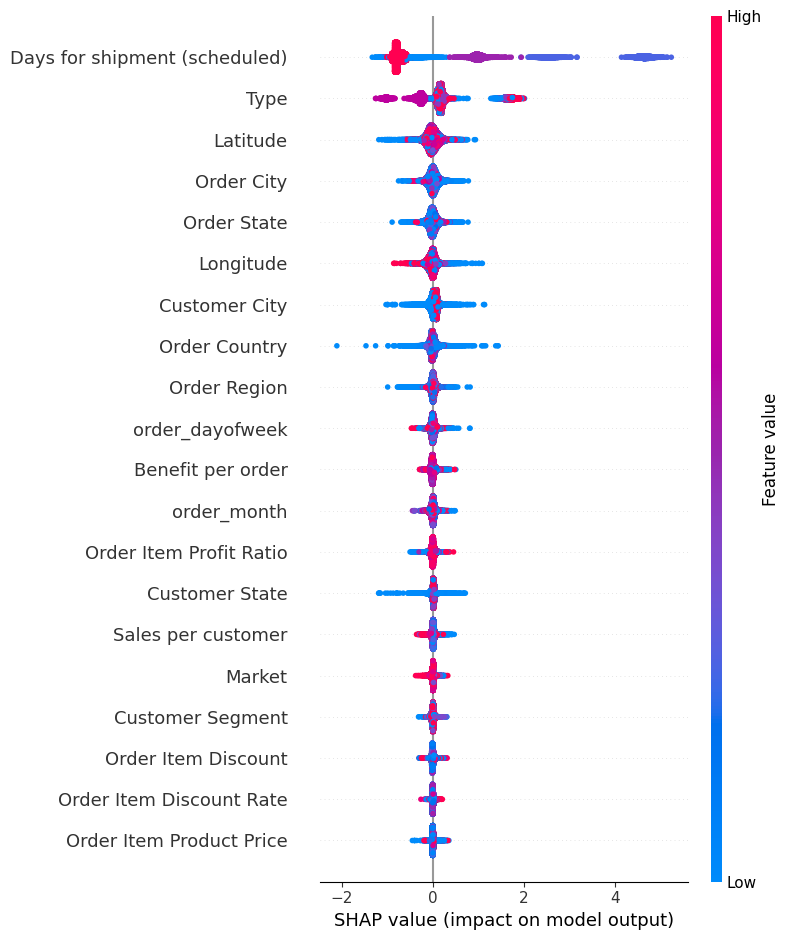

In [34]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)